# 07 — Explainability: Grad-CAM and Attention Maps

Visualizes *what each model is looking at* when it makes a prediction:

* **CNN**     – Grad-CAM on the final 3x3 conv (`block4.conv2`)
* **EfficientNet-B0** – Grad-CAM on the final feature block (`features[-1]`)
* **Swin-Tiny**       – Grad-CAM on the last block's `norm2`, with channels-last reshape

We pick one test image per class (4 total) plus a few **misclassified**
examples to see where the models look when they're wrong — essential
for clinical trust and viva defense.

Outputs:
* `outputs/gradcam/correct_per_class.png`     — 4 classes x 4 columns (orig + 3 models)
* `outputs/gradcam/misclassified.png`         — cases where the ensemble was wrong
* `outputs/gradcam/{class}_<name>.png`        — individual high-res panels

In [1]:
# --- 0. Setup ---------------------------------------------------------
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src' / '__init__.py').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from src.config         import (
    CLASS_NAMES, NUM_CLASSES, IMG_SIZE, BATCH_SIZE, NUM_WORKERS,
    OUTPUTS_DIR, MODELS_DIR, TEST_DIR,
)
from src.data_loader    import build_splits
from src.ensemble       import load_all_models, weighted_average, collect_probs, EnsembleConfig
from src.explainability import (
    load_image_for_explain, make_cnn_gradcam,
    make_efficientnet_gradcam, make_swin_gradcam, overlay_heatmap,
)
from src.utils          import get_device, set_seed

set_seed(42)
device = get_device()
sns.set_theme(style='white', context='notebook')
print(f'Device: {device}')

GRADCAM_DIR = OUTPUTS_DIR / 'gradcam'
GRADCAM_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda


## 1. Load the three trained models + the ensemble config

In [2]:
models = load_all_models(
    device,
    cnn_path      = MODELS_DIR / 'cnn_model.pth',
    transfer_path = MODELS_DIR / 'transfer_model.pth',
    swin_path     = MODELS_DIR / 'swin_model.pth',
)
ec = EnsembleConfig.load(MODELS_DIR / 'ensemble_config.json')
print(f'Loaded models : {list(models.keys())}')
print(f'Ensemble      : {ec.method} {ec.weights}')

# Build CAM extractors once and reuse
cams = {
    'cnn':      make_cnn_gradcam(models['cnn']),
    'transfer': make_efficientnet_gradcam(models['transfer']),
    'swin':     make_swin_gradcam(models['swin']),
}
pretty = {'cnn': 'Custom CNN', 'transfer': 'EfficientNet-B0', 'swin': 'Swin-Tiny'}

Loaded models : ['cnn', 'transfer', 'swin']
Ensemble      : weighted [0.0, 0.8999999761581421, 0.10000000149011612]


## 2. Pick one correctly-classified TEST image per class

We use the ensemble's predictions to select the samples — if all three
models agree on a correct call, the explanation is the cleanest.

In [3]:
# Index the test set deterministically.
_, _, test_df = build_splits()

samples = []
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    # First few candidates -- we'll predict on each and grab the first
    # one where ALL three models predict the correct class (clean case).
    cls_files = test_df.loc[test_df['class'] == cls_name, 'filepath'].head(20).tolist()
    picked = None
    for path in cls_files:
        tensor, _ = load_image_for_explain(path, IMG_SIZE)
        x = tensor.unsqueeze(0).to(device)
        with torch.no_grad():
            preds = {n: int(m(x).argmax(1).item()) for n, m in models.items()}
        if all(p == cls_idx for p in preds.values()):
            picked = path
            break
    if picked is None:
        picked = cls_files[0]   # fall back to first if no perfect agreement
    samples.append((cls_idx, cls_name, picked))
    print(f'  {cls_name:12s} -> {Path(picked).name}')

  glioma       -> Te-gl_10.jpg
  meningioma   -> Te-aug-me_1.jpg
  notumor      -> Te-no_1.jpg
  pituitary    -> Te-pi_1.jpg


## 3. Grid: 4 classes x [Original + 3 Grad-CAMs]

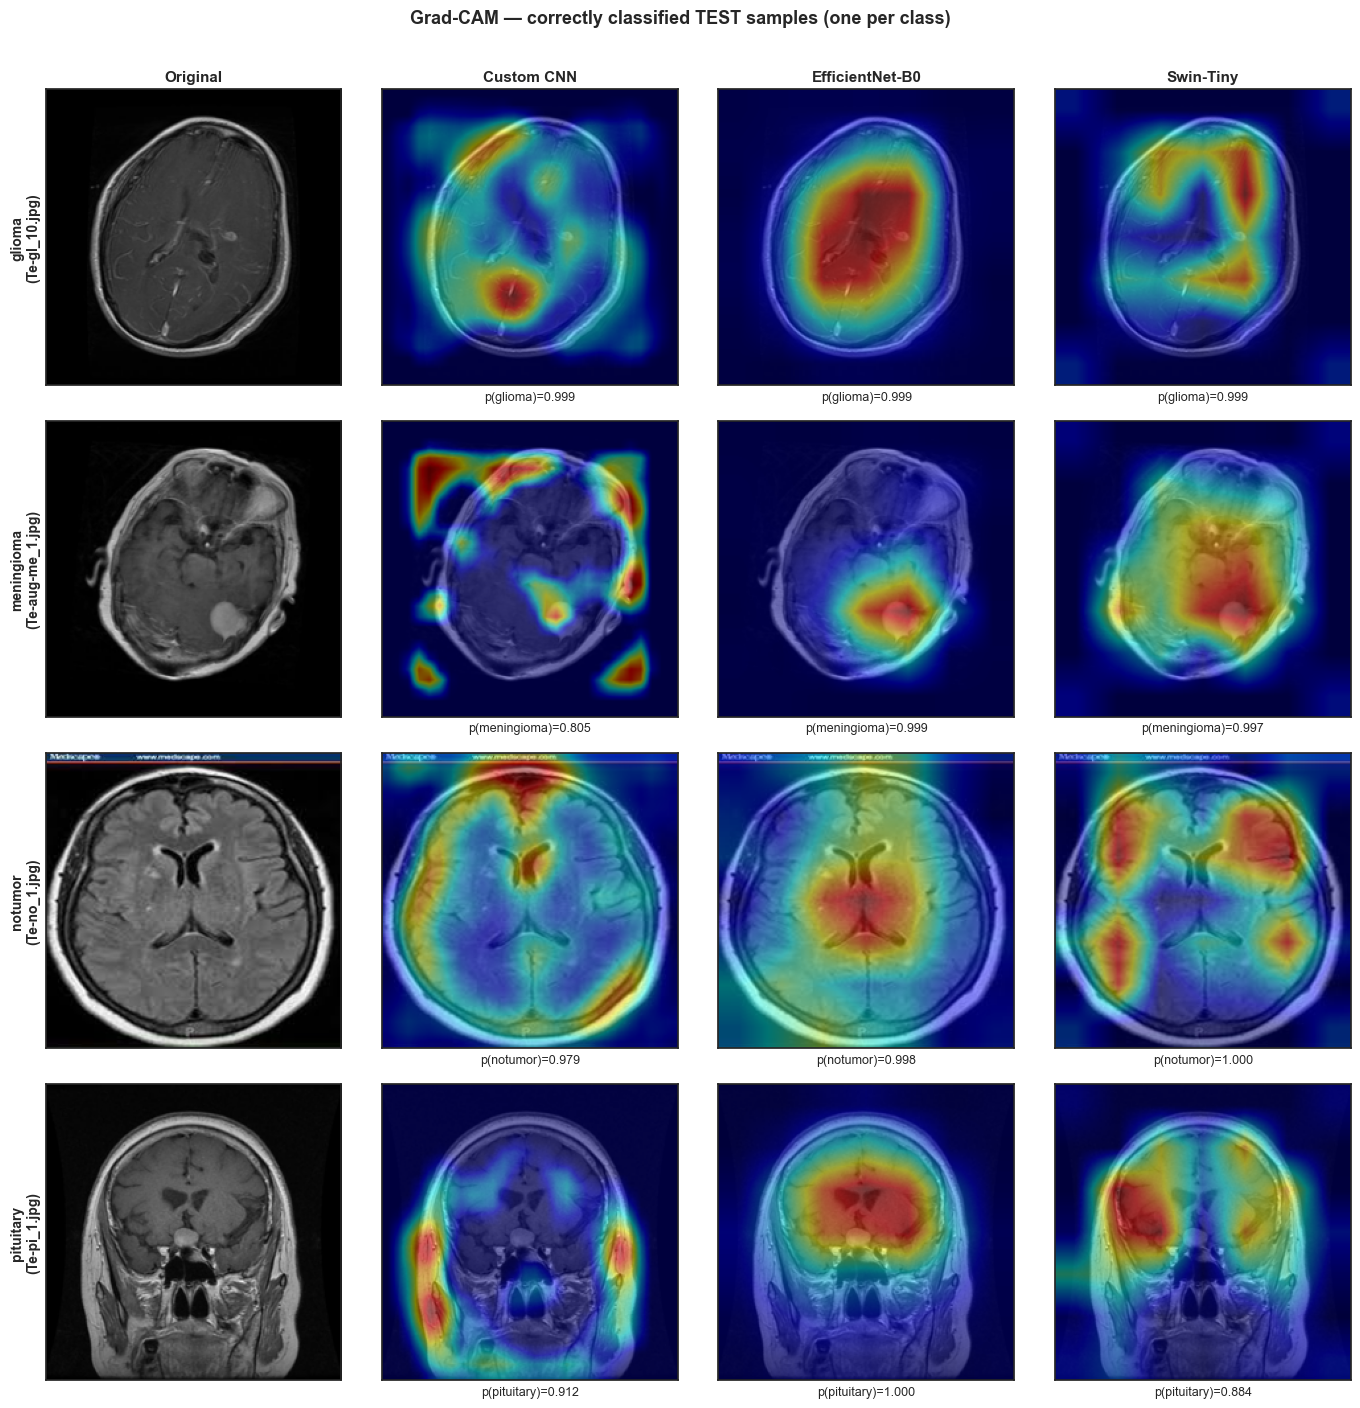

In [4]:
fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(14, 3.5 * NUM_CLASSES))
for row, (cls_idx, cls_name, path) in enumerate(samples):
    tensor, rgb01 = load_image_for_explain(path, IMG_SIZE)
    x = tensor.unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(cls_idx)]

    # Column 0: original
    axes[row, 0].imshow(rgb01)
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    axes[row, 0].set_ylabel(f'{cls_name}\n({Path(path).name})',
                            fontsize=10, fontweight='bold')
    if row == 0:
        axes[row, 0].set_title('Original', fontsize=11, fontweight='bold')

    # Columns 1-3: each model's Grad-CAM overlay
    for col, name in enumerate(['cnn', 'transfer', 'swin'], start=1):
        gray = cams[name](input_tensor=x, targets=targets)[0]
        ov   = overlay_heatmap(rgb01, gray, alpha=0.45)
        # Re-predict to label the panel with confidence
        with torch.no_grad():
            probs = torch.softmax(models[name](x), dim=-1)[0]
        conf = float(probs[cls_idx])
        axes[row, col].imshow(ov)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
        if row == 0:
            axes[row, col].set_title(pretty[name], fontsize=11, fontweight='bold')
        axes[row, col].set_xlabel(f'p({cls_name})={conf:.3f}', fontsize=9)

fig.suptitle('Grad-CAM — correctly classified TEST samples (one per class)',
             fontsize=13, fontweight='bold', y=1.005)
fig.tight_layout()
fig.savefig(GRADCAM_DIR / 'correct_per_class.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Where do the models look when they're WRONG?

We find images where the ensemble misclassified, then visualize what
each model focused on. Patterns to look for:

* All three looking at the *correct* region but disagreeing on class -> ambiguous case
* Some models looking at non-anatomical regions (corners, text) -> spurious cue exploitation
* Different models attending to different regions -> ensemble had genuine diversity but the dominant cue still misled it

In [5]:
# Reuse the ensemble's test-set predictions to find misclassified examples.
# We do a fresh collect_probs over the test set to align with the ensemble.
from torch.utils.data import DataLoader
from src.data_loader import get_dataloaders
_, _, test_loader = get_dataloaders(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)

probs_each = {}
labels_test = None
for name, m in models.items():
    p, y = collect_probs(m, test_loader, device, desc=f'{name} for misclass')
    probs_each[name] = p
    labels_test = y if labels_test is None else labels_test

ens_probs = weighted_average(
    [probs_each['cnn'], probs_each['transfer'], probs_each['swin']],
    ec.weights,
)
ens_pred = ens_probs.argmax(axis=1)

wrong_idx = np.where(ens_pred != labels_test)[0]
print(f'Ensemble misclassified {len(wrong_idx)} / {len(labels_test)} test images.')

# Pick the 4 most confidently-wrong (highest p of the wrong class).
wrong_confidences = ens_probs[wrong_idx, ens_pred[wrong_idx]]
top_wrong = wrong_idx[np.argsort(wrong_confidences)[::-1][:4]]

# Map test_loader index -> filepath. test_loader iterates in order over test_df.
_, _, test_df_full = build_splits()

for i in top_wrong:
    true_c = CLASS_NAMES[labels_test[i]]
    pred_c = CLASS_NAMES[ens_pred[i]]
    conf   = ens_probs[i, ens_pred[i]]
    print(f'  idx={i:4d}  true={true_c:11s}  pred={pred_c:11s}  '
          f'ensemble_conf={conf:.3f}  file={Path(test_df_full.iloc[i]["filepath"]).name}')

cnn for misclass:   0%|          | 0/50 [00:19<?, ?it/s]

transfer for misclass:   0%|          | 0/50 [00:00<?, ?it/s]

swin for misclass:   0%|          | 0/50 [00:00<?, ?it/s]

Ensemble misclassified 85 / 1600 test images.
  idx= 269  true=glioma       pred=notumor      ensemble_conf=0.999  file=Te-gl_341.jpg
  idx=  11  true=glioma       pred=meningioma   ensemble_conf=0.999  file=Te-gl_109.jpg
  idx= 303  true=glioma       pred=notumor      ensemble_conf=0.999  file=Te-gl_372.jpg
  idx= 365  true=glioma       pred=meningioma   ensemble_conf=0.998  file=Te-gl_68.jpg


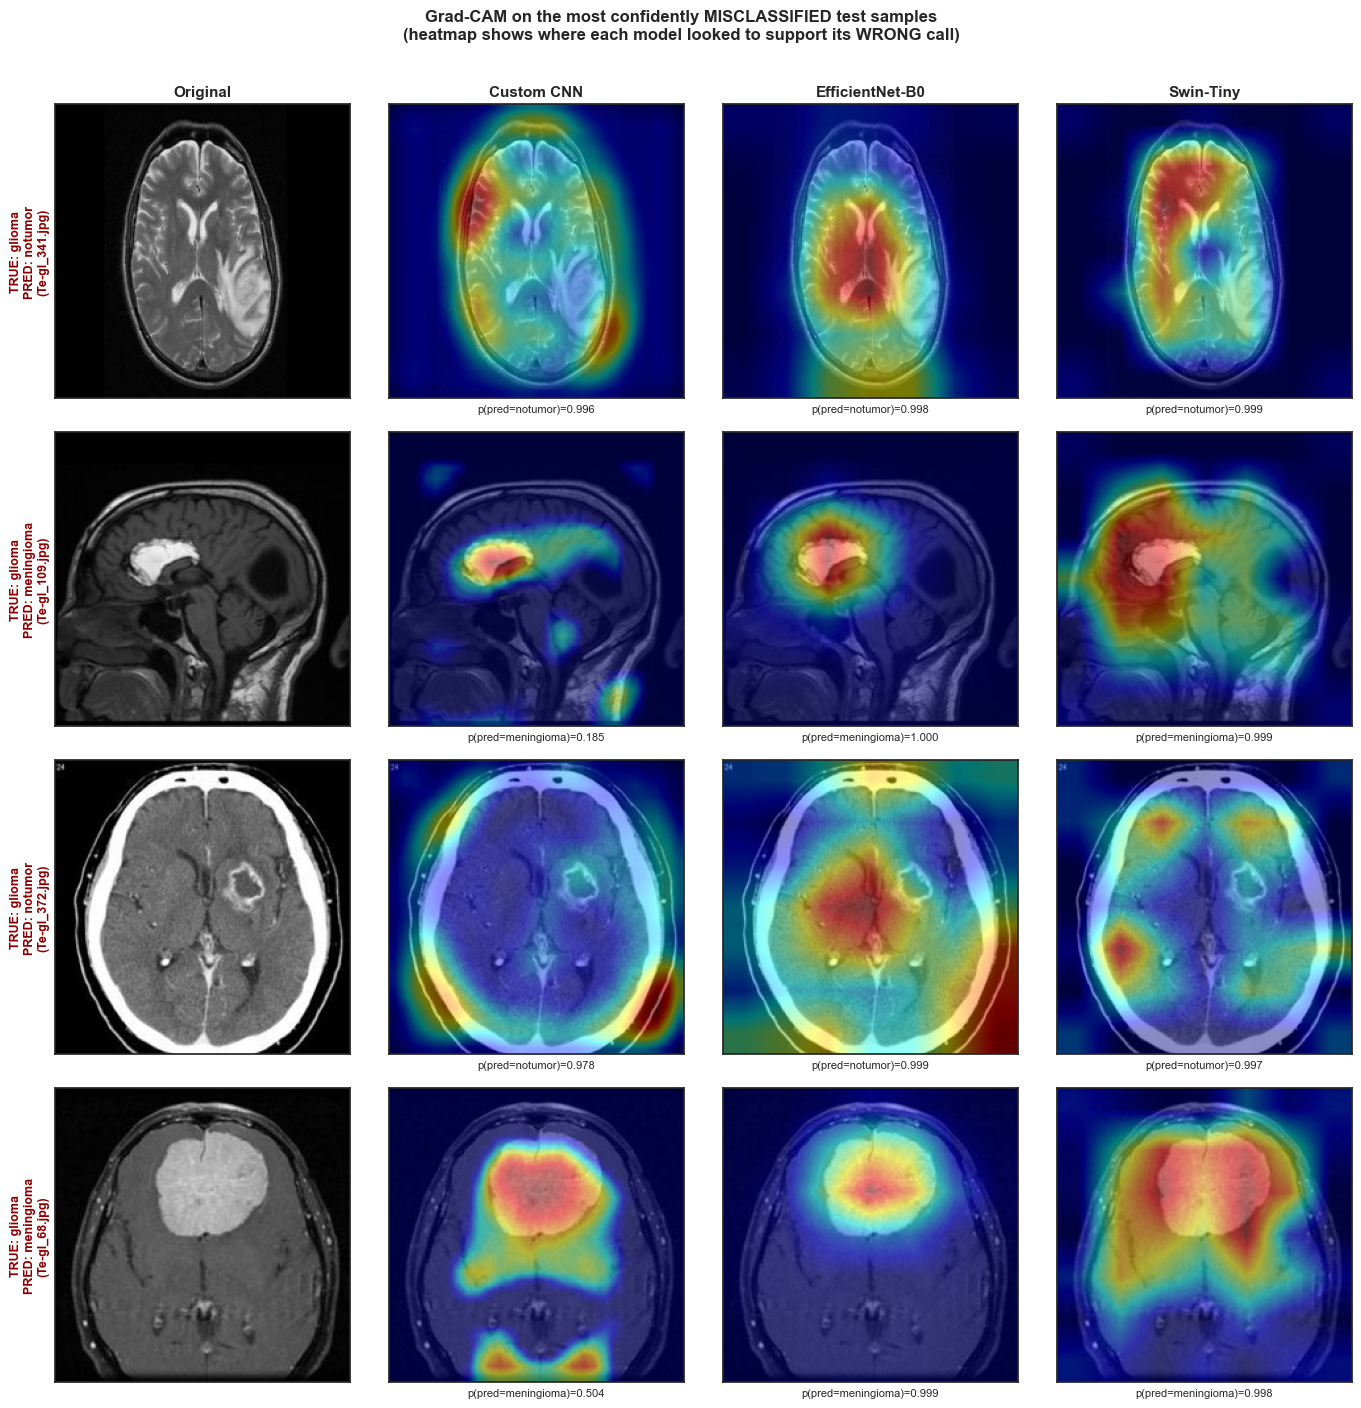

In [6]:
# Render the misclassified grid: rows=images, cols=[original + 3 Grad-CAMs]
n_wrong = len(top_wrong)
fig, axes = plt.subplots(n_wrong, 4, figsize=(14, 3.5 * n_wrong))
if n_wrong == 1:
    axes = axes[None, :]

for row, i in enumerate(top_wrong):
    true_c = labels_test[i]
    pred_c = int(ens_pred[i])
    path = test_df_full.iloc[i]['filepath']

    tensor, rgb01 = load_image_for_explain(path, IMG_SIZE)
    x = tensor.unsqueeze(0).to(device)
    # Explain with respect to the PREDICTED (wrong) class -- shows what made the model wrong.
    targets = [ClassifierOutputTarget(pred_c)]

    axes[row, 0].imshow(rgb01)
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    axes[row, 0].set_ylabel(
        f'TRUE: {CLASS_NAMES[true_c]}\n'
        f'PRED: {CLASS_NAMES[pred_c]}\n'
        f'({Path(path).name})',
        fontsize=9, fontweight='bold', color='darkred'
    )
    if row == 0:
        axes[row, 0].set_title('Original', fontsize=11, fontweight='bold')

    for col, name in enumerate(['cnn', 'transfer', 'swin'], start=1):
        gray = cams[name](input_tensor=x, targets=targets)[0]
        ov   = overlay_heatmap(rgb01, gray, alpha=0.45)
        with torch.no_grad():
            probs = torch.softmax(models[name](x), dim=-1)[0]
        axes[row, col].imshow(ov)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
        if row == 0:
            axes[row, col].set_title(pretty[name], fontsize=11, fontweight='bold')
        axes[row, col].set_xlabel(
            f'p(pred={CLASS_NAMES[pred_c]})={float(probs[pred_c]):.3f}',
            fontsize=8
        )

fig.suptitle('Grad-CAM on the most confidently MISCLASSIFIED test samples\n'
             '(heatmap shows where each model looked to support its WRONG call)',
             fontsize=12, fontweight='bold', y=1.005)
fig.tight_layout()
fig.savefig(GRADCAM_DIR / 'misclassified.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Interpreting the heatmaps

For each row in the correct-class grid, ideally:

* The CNN heatmap should highlight the **tumor region** or, for `notumor`,
  the **brain parenchyma** (not the skull or background).
* EfficientNet should produce a slightly broader but anatomically grounded heatmap.
* Swin's attention is typically *more diffuse* than the CNNs' because
  self-attention pools information globally — a normal artifact of the
  architecture, not a problem.

For misclassified rows, look for:

* Heat on the skull boundary or scanner artifacts -> spurious cue
* Heat on the wrong anatomical region -> the model saw a real but misleading feature
* Two models agreeing geographically but disagreeing on class -> classes are visually similar

## 6. Summary

Artifacts produced:

* `outputs/gradcam/correct_per_class.png`   — 4 classes x 4 columns
* `outputs/gradcam/misclassified.png`       — 4 confident-but-wrong examples

**Next:** STEP 17 — single-image inference API (used by the Streamlit app).